In [1]:
import numpy as np
import numba as nb
from scipy.integrate import quad
from sympy import fourier_series, pi
from sympy import * 
import scipy.special as special
from scipy.special import i0
#import random
import math
from scipy.integrate import simpson

import matplotlib.pyplot as plt
#from scipy.stats import gaussian_kde
import h5py
import scipy.integrate as integrate
from scipy.stats import gaussian_kde
plt.rcParams['text.usetex'] = True

In [36]:
Nn = 100
L = 25.0
m = 1.0
beta = 1
lam = 1/np.sqrt(Nn)
U0 = 10
Ul = U0 * lam
g = 5
wDrive = 0
k = 2 * np.pi / L
Ulk = Ul*k

G = 10.0
Gmk = G*m*k

dt = 5e-3
tmax = 1000
nSteps = int(np.ceil(tmax / dt))
Psi0 = 1
vc = np.sqrt(m*G/m)

In [3]:
lam*g

0.05

In [4]:
# =========================
# Core rate functions
# =========================
def cyclic_next(s):
    return {"a": "b", "b": "c", "c": "a"}[s]

def cyclic_prev(s):
    return cyclic_next(cyclic_next(s))

def W_term(eta, eta_prime):
    if eta_prime == cyclic_next(eta):
        return wDrive
    elif eta_prime == cyclic_prev(eta):
        return -wDrive
    else:
        return 0.0

def UInt(x):
    return Ul*np.cos(k*x)

def dU(x):
    return -U0*lam*k*np.sin(k*x)

def Psi(x):
    return Psi0*g*lam*np.cos(k*x+phi) #integrate.quad(lambda x: dPsi(x), 0, y)[0] #Psi0*gg*lam*np.exp(p*np.cos(k*x+phi)) #Psi0*gg*lam*np.cos(k*x+phi)
# -delta*Psi0*lam*x*np.sign(np.sin(k*x+phi))
def dPsi(x):
    return -Psi0*g*lam*k*np.sin(k*x+phi) #-gg*k*np.sin(k*x)-eps*np.tanh(np.sin(k*x))  #Psi0*gg*lam*np.exp(p*np.cos(k*x))*p*k*(-np.sin(k*x+phi)) #-Psi0*gg*lam*k*np.sin(k*x+phi)
# -delta*Psi0*lam*np.sign(np.sin(k*x+phi))
def sX(x, eta, eta_prime):
    Ueta = UInt(x) if eta == "a" else 0.0
    Ueta_p = UInt(x) if eta_prime == "a" else 0.0
    return beta * (Ueta - Ueta_p+ W_term(eta, eta_prime)) ## add work contribution

def kRate(x, eta, eta_prime):
    if eta == eta_prime:
        return 0.0

    # Reactivities
    if eta == "a" and eta_prime == "b":
        psi = Psi0 * (1 + lam * g * np.cos(k*x+phi))
    elif eta == "b" and eta_prime == "a":
        psi = Psi0 * (1 + lam * g * np.cos(k*x+phi))
    else:
        psi = Psi0

    return psi*np.exp(sX(x, eta, eta_prime)/2.0)

In [5]:
A=2*beta*np.cosh(beta*wDrive/2)*(np.cosh(beta*wDrive)+2)
B = np.exp(-beta*wDrive/2)*(np.exp(2*beta*wDrive)+np.exp(beta*wDrive)-2)
#gg=100
phi = np.pi/4#-np.pi/2
#delta=1*0
integrate.quad(lambda x: dU(x)*Psi(x), 0, L)[0]*Nn*(3*np.sinh(beta*wDrive)+np.cosh(beta*wDrive)-1)/(9*(2*np.cosh(beta*wDrive)+1))

0.0

In [6]:
2*beta*np.exp(beta*wDrive/2)*np.cosh(beta*wDrive/2)*(np.cosh(beta*wDrive)+2)*U0

60.0

In [7]:
g*Psi0*(2-np.exp(2*beta*wDrive)-np.exp(beta*wDrive))

0.0

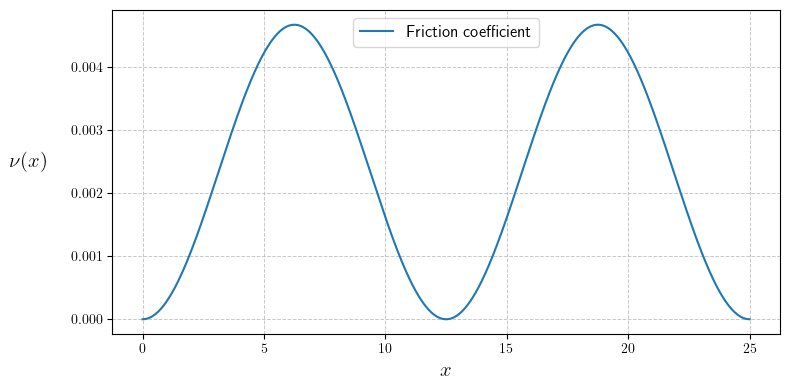

In [8]:
xL=np.linspace(0,L,1000)
nu=(A*(dU(xL))**2+B*dU(xL)*dPsi(xL))*1/(9*(2*np.cosh(beta*wDrive)+1)**2)*Nn
fig, ax = plt.subplots(figsize=(8, 4))
#plt.hist(xredstation, bins = "auto", density = True, label = "Reduced dynamics")
plt.plot(xL, nu, label = "Friction coefficient")
ax.set_ylabel(r"$\nu(x)$", fontsize = 15, rotation = 0,labelpad=30)
ax.set_xlabel(r"$x$", fontsize = 15)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
ax.legend(fontsize = 12)
plt.tight_layout()
plt.show()

In [9]:
not min(nu) < 0 < max(nu)

True

In [10]:
any(val < 0 for val in nu)

False

In [11]:
any(val > 0 for val in nu)

True

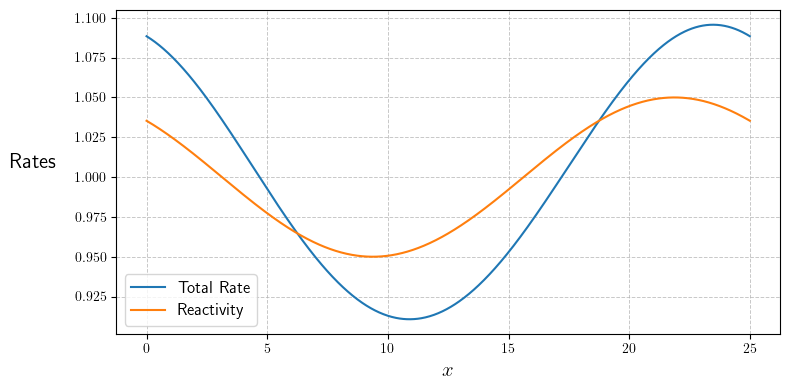

In [12]:
xL=np.linspace(0,L,1000)
fig, ax = plt.subplots(figsize=(8, 4))
#plt.hist(xredstation, bins = "auto", density = True, label = "Reduced dynamics")
plt.plot(xL, kRate(xL,"a","b"), label = "Total Rate")
plt.plot(xL,Psi0 * (1 + lam * g * np.cos(k*xL+phi)),  label = "Reactivity")
ax.set_ylabel(r"Rates", fontsize = 15, rotation = 0,labelpad=30)
ax.set_xlabel(r"$x$", fontsize = 15)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
ax.legend(fontsize = 12)
plt.tight_layout()
plt.show()

In [13]:
any(val > 0 for val in 1+Psi(xL))

True

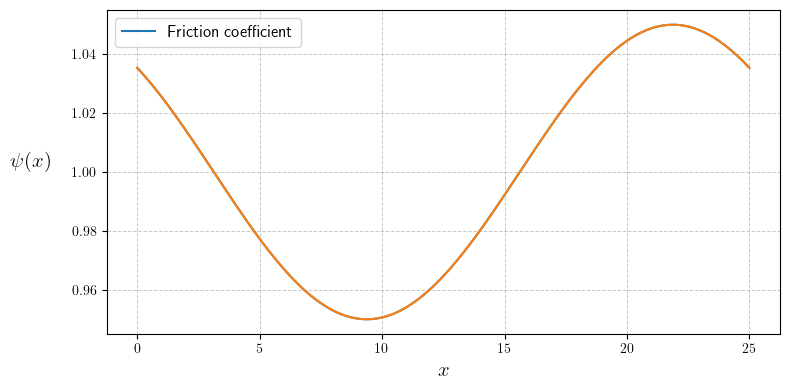

In [14]:
xL=np.linspace(0,L,1000)
fig, ax = plt.subplots(figsize=(8, 4))
#plt.hist(xredstation, bins = "auto", density = True, label = "Reduced dynamics")
plt.plot(xL, 1+Psi(xL), label = "Friction coefficient")
plt.plot(xL,Psi0 * (1 + lam * g * np.cos(k*xL+phi)))
ax.set_ylabel(r"$\psi(x)$", fontsize = 15, rotation = 0,labelpad=30)
ax.set_xlabel(r"$x$", fontsize = 15)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
ax.legend(fontsize = 12)
plt.tight_layout()
plt.show()

In [15]:
# =========================
# Vectorized Simulation
# =========================

def simulate(init_state, init_x, init_v):
    x = init_x
    v = init_v
    eta = np.array(init_state, dtype=object)
    t = 0.0

    times = np.zeros(nSteps + 1)
    xs = np.zeros(nSteps + 1)
    vs = np.zeros(nSteps + 1)
    etas = np.empty((nSteps + 1, Nn), dtype=object)

    xs[0] = x
    vs[0] = v
    etas[0] = eta.copy()

    for i in range(nSteps):

        # ===== Velocity Verlet =====
        # Force at current (x, η)
        nA = np.sum(eta == "a")
        acc = (-Gmk * np.sin(k * x) + nA * Ulk * np.sin(k * x)) / m
        
        # Update everything forward
        v = v + acc * dt
        x = (x + v * dt) % L   

        # ===== Compute rates at current x =====
        rA = np.array([kRate(x, "a", "b"), kRate(x, "a", "c")])
        rB = np.array([kRate(x, "b", "a"), kRate(x, "b", "c")])
        rC = np.array([kRate(x, "c", "a"), kRate(x, "c", "b")])

        totalRates = {
            "a": np.sum(rA),
            "b": np.sum(rB),
            "c": np.sum(rC)
        }

        # ===== Vectorized jump decision =====
        total_vec = np.vectorize(totalRates.get)(eta)
        jump_probs = 1 - np.exp(-total_vec * dt)
        jump_mask = np.random.rand(Nn) < jump_probs

        rands = np.random.rand(Nn)
        u = rands * total_vec

        # Masks per state
        maskA = (eta == "a") & jump_mask
        maskB = (eta == "b") & jump_mask
        maskC = (eta == "c") & jump_mask

        # Allocate new states
        new_eta = eta.copy()

        # State A transitions
        new_eta[maskA & (u < rA[0])] = "b"
        new_eta[maskA & (u >= rA[0])] = "c"

        # State B transitions
        new_eta[maskB & (u < rB[0])] = "a"
        new_eta[maskB & (u >= rB[0])] = "c"

        # State C transitions
        new_eta[maskC & (u < rC[0])] = "a"
        new_eta[maskC & (u >= rC[0])] = "b"

        eta = new_eta

        # ===== Store =====
        t += dt
        times[i + 1] = t
        xs[i + 1] = x
        vs[i + 1] = v
        etas[i + 1] = eta.copy()

    return {
        "times": times,
        "x": xs,
        "v": vs,
        "eta": etas
    }

# Equilibrium results #

In [56]:
## Equilibrium case ##
def potV(x):
    return -G*m*np.cos(k*x)
def rho1(x):
    return np.exp(-beta*potV(x))*intexpU(x)**N_colloids
def marginalv(v):
    return np.exp(-beta*m*v**2/(2))/np.sqrt(2*np.pi/(m*beta))
def rho_x(x):
   return rho1(x)/Z1
def marginalx(x):
    return 1/Zx*np.exp(-beta*potV(x))
def intexpU(x):
    return 1+1+np.exp(-beta*UInt(x)) #integrate.quad(lambda y: np.exp(-beta*UInt(x)),0,L)[0]

N_colloids = Nn  # make sure N_colloids matches your system size
Zx=integrate.quad(lambda x: np.exp(-beta*potV(x)), 0, L)[0]
Z1=integrate.quad(lambda x: rho1(x), 0, L)[0]

In [57]:
xline = np.linspace(0,L,1000)
vline = np.linspace(-10,10,1000)
rho_x_vals = np.array([rho_x(x) for x in xline])
Vx=potV(xline)
minindex=np.where(Vx == Vx.min())[0][0]
xmin=xline[minindex]
avx=integrate.quad(lambda x: x*rho_x(x), 0, L)[0]
avx2= integrate.quad(lambda x: x**2*rho_x(x), 0, L)[0]
varx=avx2-avx**2

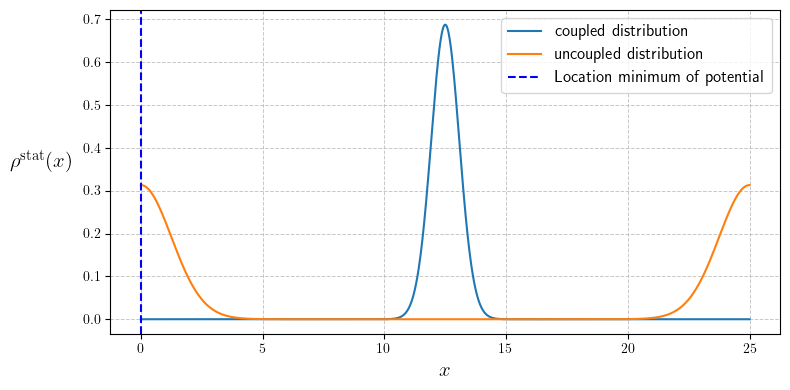

In [58]:
fig, ax = plt.subplots(figsize=(8, 4))
plt.plot(xline, rho_x_vals, label = 'coupled distribution')
plt.plot(xline, marginalx(xline), label = 'uncoupled distribution')
#plt.plot(xline, marginalx(xline))
plt.axvline(x = xmin, color = 'b', label = 'Location minimum of potential', linestyle = '--')
ax.set_ylabel(r"$\rho^\mathrm{stat}(x)$", fontsize = 15, rotation = 0,labelpad=30)
ax.set_xlabel(r"$x$", fontsize = 15)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
ax.legend(fontsize = 12)
plt.tight_layout()
plt.show()

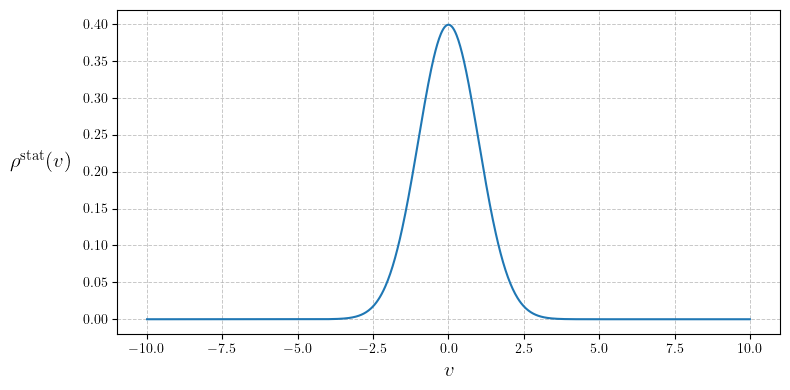

In [59]:
fig, ax = plt.subplots(figsize=(8, 4))
plt.plot(vline, marginalv(vline))
ax.set_ylabel(r"$\rho^\mathrm{stat}(v)$", fontsize = 15, rotation = 0,labelpad=30)
ax.set_xlabel(r"$v$", fontsize = 15)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
#ax.legend(fontsize = 12)
plt.tight_layout()
plt.show()

# 1 Run #

In [63]:
eta0 = np.random.choice(["a", "b", "c"], size=Nn)
x0 = L/2
v0 = 1
test = simulate(eta0, x0, v0)

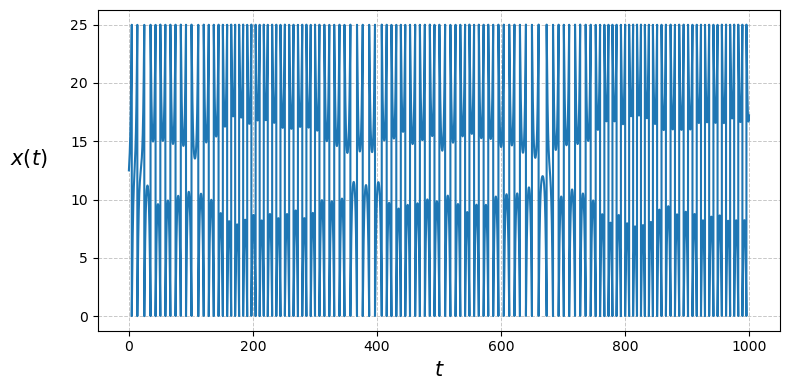

In [64]:
fig, ax = plt.subplots(figsize=(8, 4))
plt.plot(test["times"], test["x"])
ax.set_ylabel(r"$x(t)$", fontsize = 15, rotation = 0,labelpad=30)
ax.set_xlabel(r"$t$", fontsize = 15)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
#ax.legend(fontsize = 12)
plt.tight_layout()
plt.show()

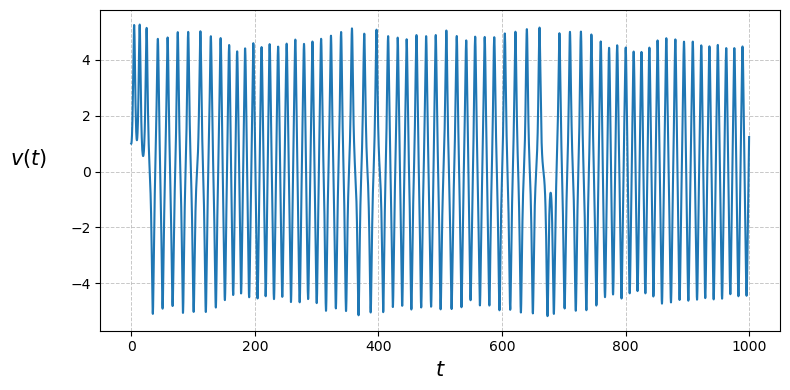

In [65]:
fig, ax = plt.subplots(figsize=(8, 4))
plt.plot(test["times"], test["v"])
ax.set_ylabel(r"$v(t)$", fontsize = 15, rotation = 0,labelpad=30)
ax.set_xlabel(r"$t$", fontsize = 15)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
#ax.legend(fontsize = 12)
plt.tight_layout()
plt.show()

# Dynamics over many runs #

In [43]:
x0 = L/2
v0 = 1
trials = 50
# Arrays to store all paths
x_all = np.zeros((trials, nSteps + 1))
v_all = np.zeros((trials, nSteps + 1))
N_colloids = Nn  # make sure N_colloids matches your system size

for i in range(trials):
    # Random initial states
    eta0 = np.random.choice(["a", "b", "c"], size=N_colloids)
    
    # Run simulation
    res = simulate(eta0, x0, v0)
    x_all[i, :] = res["x"]
    v_all[i, :] = res["v"]
    
    print(f"Trial {i+1} done")

x_mean = np.mean(x_all, axis=0)
v_mean = np.mean(v_all, axis=0)

# Standard deviation (for envelope)
x_std = np.std(x_all, axis=0)
v_std = np.std(v_all, axis=0)

Trial 1 done
Trial 2 done
Trial 3 done
Trial 4 done
Trial 5 done
Trial 6 done
Trial 7 done
Trial 8 done
Trial 9 done
Trial 10 done
Trial 11 done
Trial 12 done
Trial 13 done
Trial 14 done
Trial 15 done
Trial 16 done
Trial 17 done
Trial 18 done
Trial 19 done
Trial 20 done
Trial 21 done
Trial 22 done
Trial 23 done
Trial 24 done
Trial 25 done
Trial 26 done
Trial 27 done
Trial 28 done
Trial 29 done
Trial 30 done
Trial 31 done
Trial 32 done
Trial 33 done
Trial 34 done
Trial 35 done
Trial 36 done
Trial 37 done
Trial 38 done
Trial 39 done
Trial 40 done
Trial 41 done
Trial 42 done
Trial 43 done
Trial 44 done
Trial 45 done
Trial 46 done
Trial 47 done
Trial 48 done
Trial 49 done
Trial 50 done


In [66]:
x_mean = np.mean(x_all, axis=0)
v_mean = np.mean(v_all, axis=0)

# Standard deviation (for envelope)
x_std = np.std(x_all, axis=0)
v_std = np.std(v_all, axis=0)

In [285]:
x_all2 = np.vstack((x_all, np.zeros((trials, nSteps + 1))))
v_all2 = np.vstack((v_all, np.zeros((trials, nSteps + 1))))

In [112]:
round = 1
x0 = L/4
v0 = 1.0
trials = 50
# Arrays to store all paths
#x_all = np.zeros((trials, nSteps + 1))
#v_all = np.zeros((trials, nSteps + 1))
N_colloids = Nn  # make sure N_colloids matches your system size

for i in range(trials, 2*trials):
    # Random initial states
    eta0 = np.random.choice(["a", "b", "c"], size=N_colloids)
    
    # Run simulation
    res = simulate(eta0, x0, v0)
    x_all2[i, :] = res["x"]
    v_all2[i, :] = res["v"]
    
    print(f"Trial {i+1} done")

x_mean = np.mean(x_all2, axis=0)
v_mean = np.mean(v_all2, axis=0)

# Standard deviation (for envelope)
x_std = np.std(x_all2, axis=0)
v_std = np.std(v_all2, axis=0)

KeyboardInterrupt: 

In [44]:
times = res["times"]

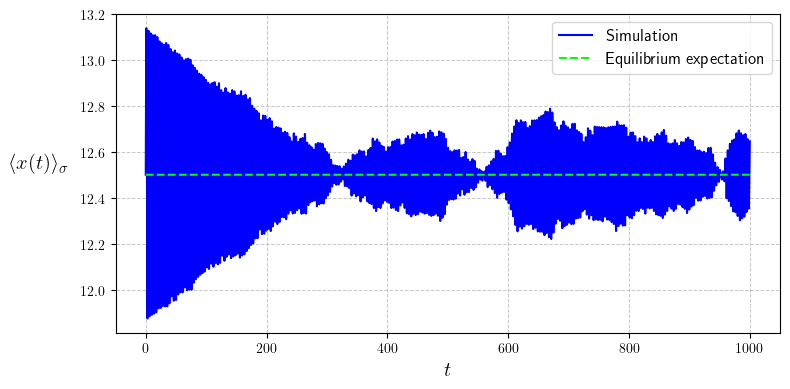

In [45]:
fig, ax = plt.subplots(figsize=(8, 4))
plt.plot(times, x_mean,label='Simulation', color = 'blue')
#plt.plot(times,xred_mean,label='Reduced dynamics', color = 'r')
plt.plot(times,times*0+avx,label='Equilibrium expectation',linestyle='--', color = 'lime')
ax.set_ylabel(r"$\langle x(t) \rangle_\sigma$", fontsize = 15, rotation = 0,labelpad=30)
ax.set_xlabel(r"$t$", fontsize = 15)
ax.legend(fontsize = 12, loc = 'upper right')
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
plt.tight_layout()
plt.show()

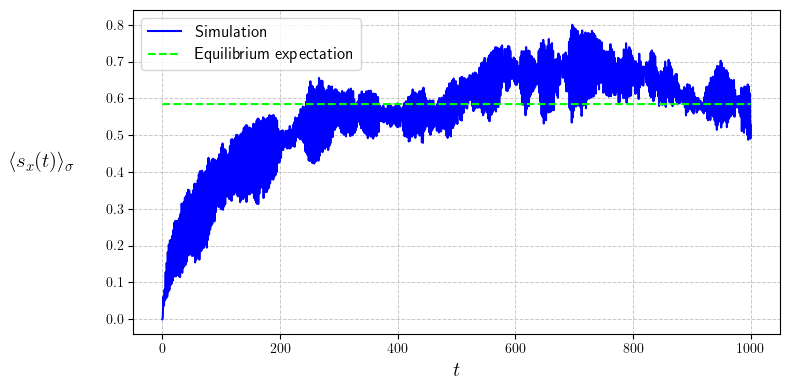

In [63]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(times, x_std, label='Simulation', color = 'blue')
ax.set_xlabel(r"$t$", fontsize = 15)
ax.set_ylabel(r"$\langle s_{x}(t) \rangle_\sigma$", fontsize = 15, rotation = 0,labelpad=45)
ax.plot(times, times*0+np.sqrt(varx), label='Equilibrium expectation', linestyle='--', color = 'lime')
ax.legend(fontsize = 12)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
plt.tight_layout()
plt.show()

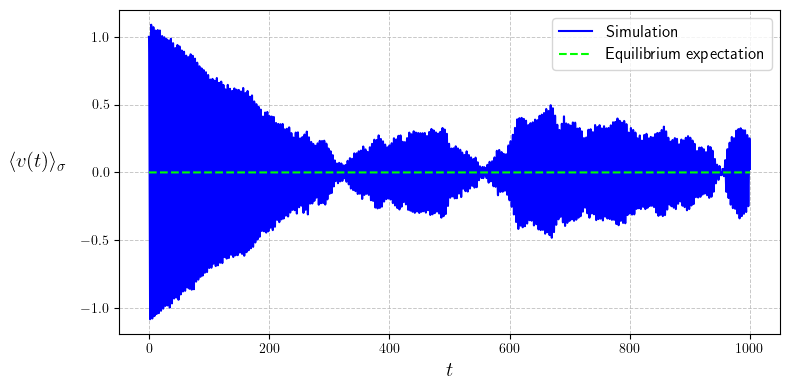

In [47]:
fig, ax = plt.subplots(figsize=(8, 4))
plt.plot(times, v_mean,label='Simulation', color = 'blue')
#plt.plot(times, vred_mean,label='Reduced dynamics', color = 'red')
ax.set_ylabel(r"$\langle v(t) \rangle_\sigma$", fontsize = 15, rotation = 0,labelpad=30)
ax.set_xlabel(r"$t$", fontsize = 15)
ax.plot(times, times*0, label='Equilibrium expectation', linestyle='--', color = 'lime')
ax.legend(fontsize = 12)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
plt.tight_layout()
plt.show()

In [48]:
times[-100000]

500.0049999996178

In [49]:
vmeanrotmax=np.mean(v_mean[-100000])
print(vmeanrotmax)

0.07583129168627029


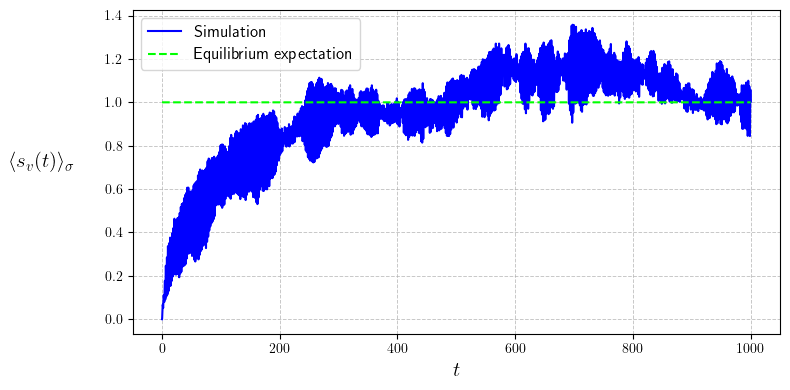

In [50]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(times, v_std, label='Simulation', color = 'blue')
ax.set_xlabel(r"$t$", fontsize = 15)
ax.set_ylabel(r"$\langle s_{v}(t) \rangle_\sigma$", fontsize = 15, rotation = 0,labelpad=45)
ax.plot(times, times*0+np.sqrt(1/(m*beta)), label='Equilibrium expectation', linestyle='--', color = 'lime')
ax.legend(fontsize = 12)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
plt.tight_layout()
plt.show()

In [30]:
svrotmax=np.mean(v_std[-100000])
print(svrotmax)

1.8427725875601215


In [31]:
len(v_all[1])

600001

In [60]:
vstation = v_all[:,-100000:].reshape(-1)
#vredstation = vred_all[:,-100000:].reshape(-1)
xstation = x_all[:,-100000:].reshape(-1)
#xredstation = xred_all[:,-100000:].reshape(-1)
vv=np.linspace(min(vstation), max(vstation), 10000)
xx = np.linspace(min(xstation), max(xstation), 10000)
rho_x_valsxx = np.array([rho_x(x) for x in xx])

In [61]:
rho_x_valsxx

array([6.52116280e-05, 6.54274769e-05, 6.56440137e-05, ...,
       1.26306862e-04, 1.25900724e-04, 1.25495838e-04])

In [91]:
vstation = v_all[:,-50000:].reshape(-1)
#vredstation = vred_all[:,-100000:].reshape(-1)
xstation = x_all[:,-50000:].reshape(-1)
#xredstation = xred_all[:,-100000:].reshape(-1)
vv=np.linspace(min(vstation), max(vstation), 10000)
xx = np.linspace(min(xstation), max(xstation), 10000)
rho_x_valsxx = np.array([rho_x(x) for x in xx])

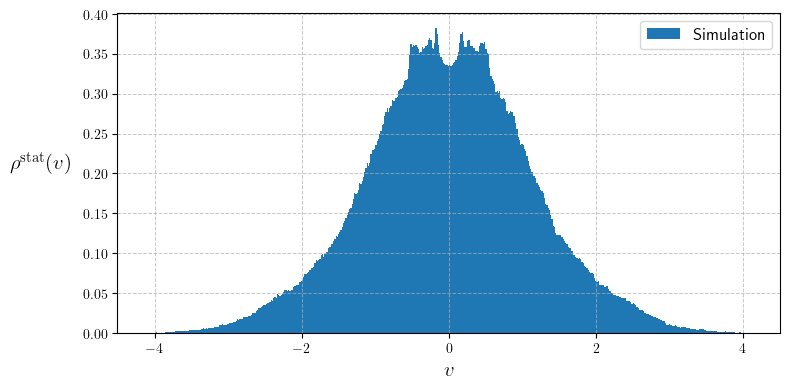

In [52]:
fig, ax = plt.subplots(figsize=(8, 4))
#plt.hist(vredstation, density = True, bins = "auto", label = "Reduced dynamics")
plt.hist(vstation, density = True, bins = "auto", label = "Simulation")
#plt.plot(vstation, np.exp(-(vstation-vmeanrotmax)**2/(2*svrotmax**2))*1/np.sqrt(2*np.pi*svrotmax**2), label = "Shifted Maxwellian", linestyle = '--', color = 'black')
#plt.plot(vv, marginalv(vv), label = "Equilibrium Distribution",color = "black", linestyle = "--")
ax.set_ylabel(r"$\rho^\mathrm{stat}(v)$", fontsize = 15, rotation = 0,labelpad=30)
ax.set_xlabel(r"$v$", fontsize = 15)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
ax.legend(fontsize = 12)
plt.tight_layout()
plt.show()

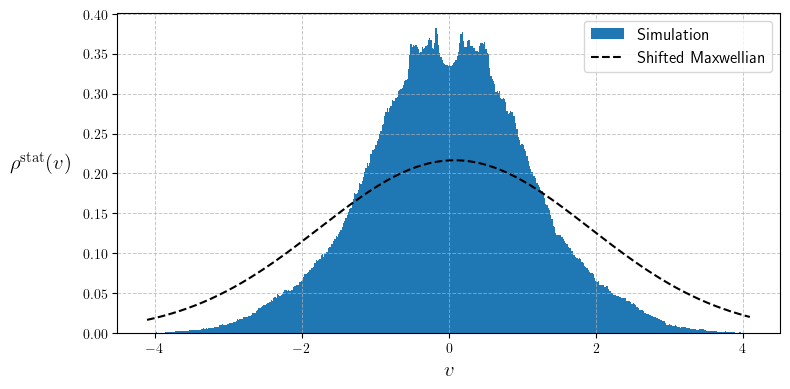

In [53]:
fig, ax = plt.subplots(figsize=(8, 4))
#plt.hist(vredstation, density = True, bins = "auto", label = "Reduced dynamics")
plt.hist(vstation, density = True, bins = "auto", label = "Simulation")
plt.plot(vv, np.exp(-(vv-vmeanrotmax)**2/(2*svrotmax**2))*1/np.sqrt(2*np.pi*svrotmax**2), label = "Shifted Maxwellian", linestyle = '--', color = 'black')
#plt.plot(vv, marginalv(vv), label = "Equilibrium Distribution",color = "black", linestyle = "--")
ax.set_ylabel(r"$\rho^\mathrm{stat}(v)$", fontsize = 15, rotation = 0,labelpad=30)
ax.set_xlabel(r"$v$", fontsize = 15)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
ax.legend(fontsize = 12)
plt.tight_layout()
plt.show()

In [36]:
kdevrotmax = gaussian_kde(vstation)
v_rangerotmax = np.linspace(min(vstation), max(vstation), 500)
normvrotmax, _ = quad(kdevrotmax, min(vstation), max(vstation))
print(normvrotmax)

0.9999921049103401


In [76]:
kdevrotneg = gaussian_kde(vstation)
v_rangerotneg = np.linspace(min(vstation), max(vstation), 500)
normvrotneg, _ = quad(kdevrotneg, min(vstation), max(vstation))
print(normvrotneg)

0.9999602026396741


In [126]:
kdevrotpos = gaussian_kde(vstation)
v_rangerotpos = np.linspace(min(vstation), max(vstation), 500)
normvrotpos, _ = quad(kdevrotpos, min(vstation), max(vstation))
print(normvrotpos)

0.9997512573027871


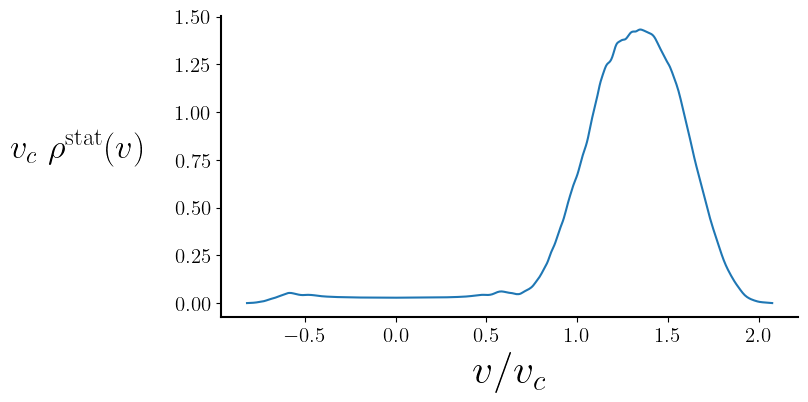

In [127]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(v_rangerotmax/vc, kdevrotmax(v_rangerotmax)*vc, label = "Simulation")
#plt.plot(vv/vc, vc*np.exp(-(vv/vc-vmeanrotmax/vc)**2/(2*svrotmax**2/vc**2))*1/np.sqrt(2*np.pi*svrotmax**2), label = "Shifted Maxwellian", linestyle = '--', color = 'black')
ax.set_ylabel(r"$v_{c} \ \rho^{\mathrm{stat}}(v)$", fontsize=25, rotation=0, labelpad=70)
ax.set_xlabel(r"$v/v_{c}$", fontsize=30)
#ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
plt.tight_layout()
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=15)
for axis in 'left', 'bottom':
    ax.spines[axis].set_linewidth(1.5)
#ax.legend(fontsize = 12)
plt.savefig('final rotation larger driving velocity distribution 50.png')
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(vv/vc, kdevrotmax(vv)*vc, label = "Simulation")
plt.plot(vv/vc, vc*np.exp(-(vv-vmeanrotmax)**2/(2*svrotmax**2))*1/np.sqrt(2*np.pi*svrotmax**2), label = "Shifted Maxwellian", linestyle = '--', color = 'black')
ax.set_ylabel(r"$v_{c} \ \rho^{\mathrm{stat}}(v)$", fontsize=25, rotation=0, labelpad=70)
ax.set_xlabel(r"$v/v_{c}$", fontsize=30)
#ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
plt.tight_layout()
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=15)
for axis in 'left', 'bottom':
    ax.spines[axis].set_linewidth(1.5)
ax.legend(fontsize = 12)
plt.show()

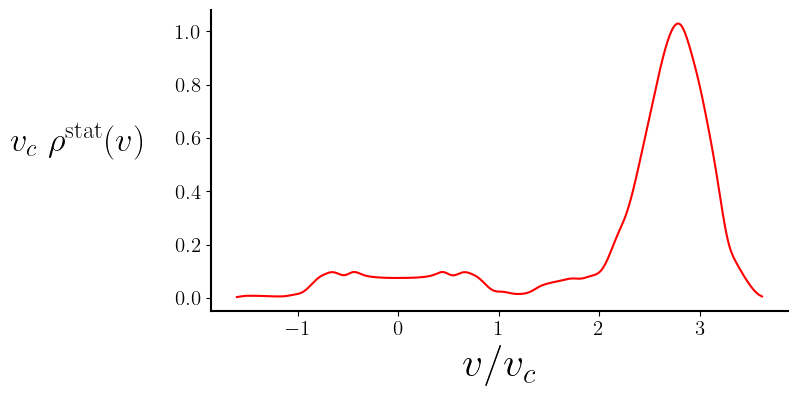

In [131]:
fig, ax = plt.subplots(figsize=(8, 4))
#ax.plot(v_rangerotneg/vc, kdevrotneg(v_rangerotneg)*vc,label = "Negative Driving", color = 'blue')
ax.plot(v_rangerotpos/vc, kdevrotpos(v_rangerotpos)*vc,label = "Positive Driving", color = 'red')
ax.set_ylabel(r"$v_{c} \ \rho^\mathrm{{stat}}(v)$", fontsize=25, rotation=0, labelpad=70)
ax.set_xlabel(r"$v/v_{c}$", fontsize=30)
#ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
plt.tight_layout()
#ax.legend(fontsize = 12)
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=15)
for axis in 'left', 'bottom':
    ax.spines[axis].set_linewidth(1.5)
#plt.savefig('final rotation negative friction velocity distribution.png')
plt.savefig('final rotation larger driving velocity distribution 50.png')
plt.show()

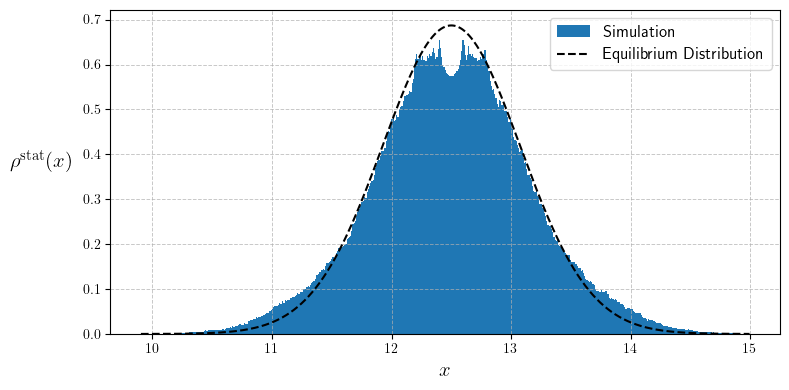

In [62]:
fig, ax = plt.subplots(figsize=(8, 4))
#plt.hist(xredstation, bins = "auto", density = True, label = "Reduced dynamics")
plt.hist(xstation,bins = "auto", density = True, label = "Simulation")
plt.plot(xx, rho_x_valsxx, label = "Equilibrium Distribution",color = "black", linestyle = "--")
ax.set_ylabel(r"$\rho^\mathrm{stat}(x)$", fontsize = 15, rotation = 0,labelpad=30)
ax.set_xlabel(r"$x$", fontsize = 15)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
ax.legend(fontsize = 12)
plt.tight_layout()
plt.show()

In [32]:
xv_all =np.multiply(x_all,v_all)

In [33]:
xv_mean = np.mean(xv_all, axis=0)

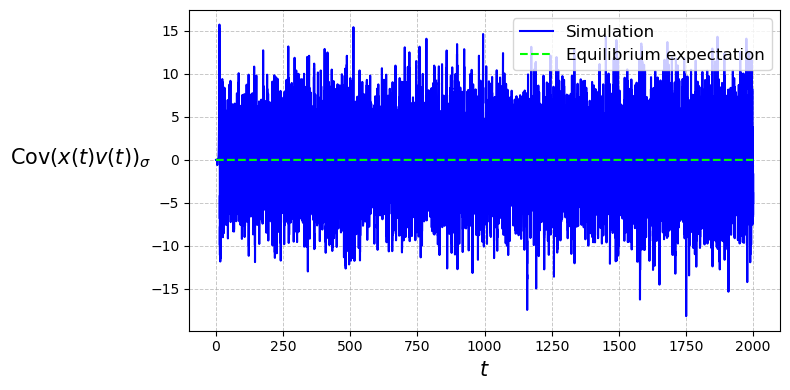

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))
plt.plot(times, xv_mean-x_mean*v_mean,label='Simulation', color = 'blue')
#plt.plot(times,xredneq100_mean,label='Reduced dynamics', color = 'r')
plt.plot(times,times*0+0,label='Equilibrium expectation',linestyle='--', color = 'lime')
ax.set_ylabel(r"$\text{Cov}(x(t) v(t))_\sigma$", fontsize = 15, rotation = 0,labelpad=50)
ax.set_xlabel(r"$t$", fontsize = 15)
ax.legend(fontsize = 12, loc = 'upper right')
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
plt.tight_layout()
plt.show()

In [35]:
xvstation =np.multiply(xstation,vstation)

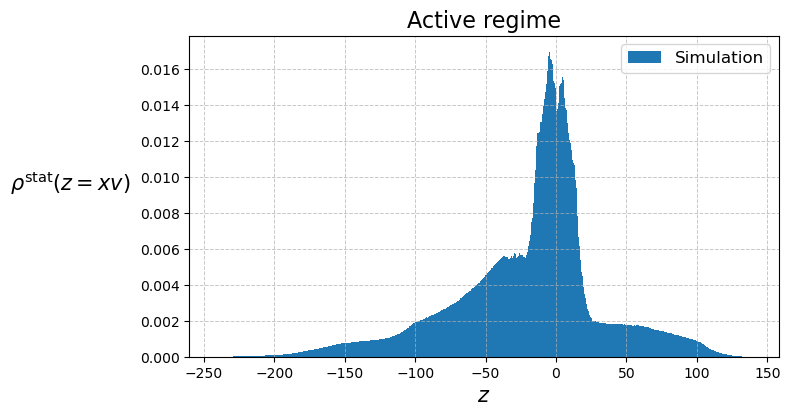

In [36]:
fig, ax = plt.subplots(figsize=(8, 4))
#plt.hist(vredstationneq100, density = True, bins = "auto", label = "Reduced dynamics")
plt.hist(xvstation, density = True, bins = "auto", label = "Simulation")
#plt.plot(vvneq50, marginalv(vvneq50), label = "Equilibrium Distribution",color = "black", linestyle = "--")
ax.set_ylabel(r"$\rho^\text{stat}(z = xv)$", fontsize = 15, rotation = 0,labelpad=50)
ax.set_xlabel(r"$z$", fontsize = 15)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
ax.legend(fontsize = 12)
plt.tight_layout()
ax.set_title("Active regime", fontsize=16)
plt.show()

In [37]:
hist2d, x_edges, v_edges = np.histogram2d(xstation, vstation, bins=100, density=True)

# ρ(x) = marginal over v → integrate along axis=1 (v axis)
rho_xc = hist2d.sum(axis=1) * np.diff(v_edges)[0]  # shape (n_x_bins,)

# ρ(v | x) = ρ(x, v) / ρ(x) → divide each row by ρ(x)
rho_v_given_x = hist2d / rho_xc[:, np.newaxis]  # shape (n_x_bins, n_v_bins)

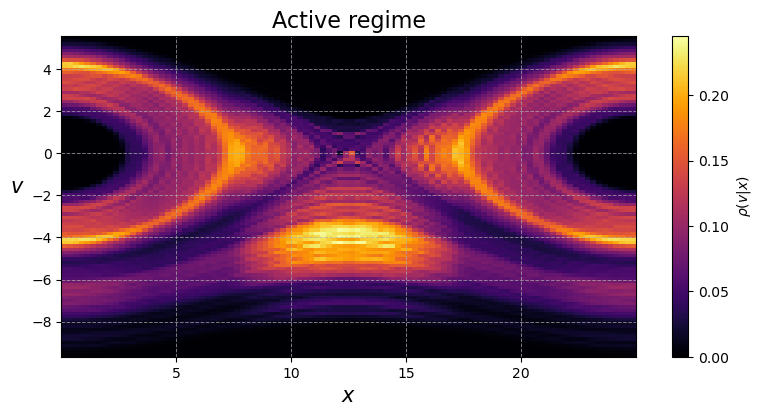

In [38]:
# Bin centers
x_centers = (x_edges[:-1] + x_edges[1:]) / 2
v_centers = (v_edges[:-1] + v_edges[1:]) / 2

fig, ax = plt.subplots(figsize=(8, 4))
plt.pcolormesh(x_centers, v_centers, rho_v_given_x.T, cmap='inferno')
# .T because pcolormesh expects shape (n_v, n_x)
plt.colorbar(label=r'$\rho(v|x)$')
ax.set_ylabel(r"$v$", fontsize = 15, rotation = 0,labelpad=10)
ax.set_xlabel(r"$x$", fontsize = 15)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
#ax.legend(fontsize = 12)
plt.tight_layout()
ax.set_title("Active regime", fontsize=16)
plt.show()

In [39]:
print(rho_v_given_x.sum(axis=1) * np.diff(v_edges)[0])  # should be all ~1.0

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


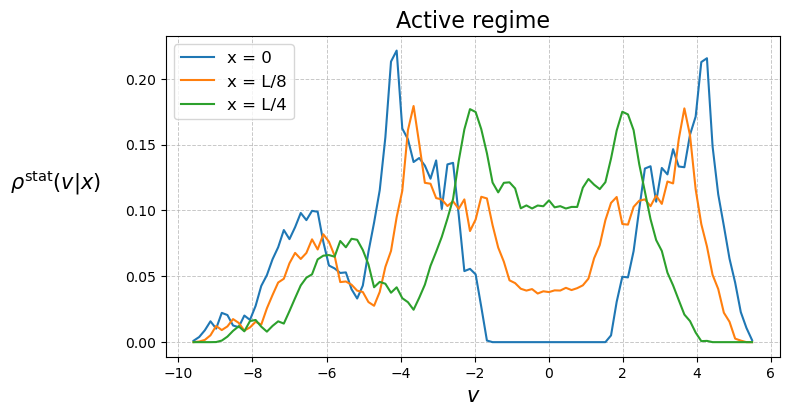

In [40]:
x_target1 = 0
ix1 = np.argmin(np.abs(x_centers - x_target1))
x_target2 = L/8
ix2 = np.argmin(np.abs(x_centers - x_target2))
x_target3 = L/4
ix3 = np.argmin(np.abs(x_centers - x_target3))
x_target4 = L/2
ix4 = np.argmin(np.abs(x_centers - x_target4))
x_target5 = L
ix5 = np.argmin(np.abs(x_centers - x_target5))

fig, ax = plt.subplots(figsize=(8, 4))
plt.plot(v_centers, rho_v_given_x[ix1, :], label = r"x = 0")
plt.plot(v_centers, rho_v_given_x[ix2, :], label = r"x = L/8")
plt.plot(v_centers, rho_v_given_x[ix3, :], label = r"x = L/4")
#plt.plot(v_centers, rho_v_given_x[ix4, :], label = r"x = $x_{min}$")
#plt.plot(v_centers, rho_v_given_x[ix4, :], label = r"x = $x_{max}$")
#plt.ylabel(r'$\rho(v | x \approx %.2f)$' % x_centers[ix])
ax.set_ylabel(r"$\rho^\text{stat}(v|x)$", fontsize = 15, rotation = 0,labelpad=50)
ax.set_xlabel(r"$v$", fontsize = 15)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
ax.legend(fontsize = 12)
plt.tight_layout()
ax.set_title("Active regime", fontsize=16)
plt.show()

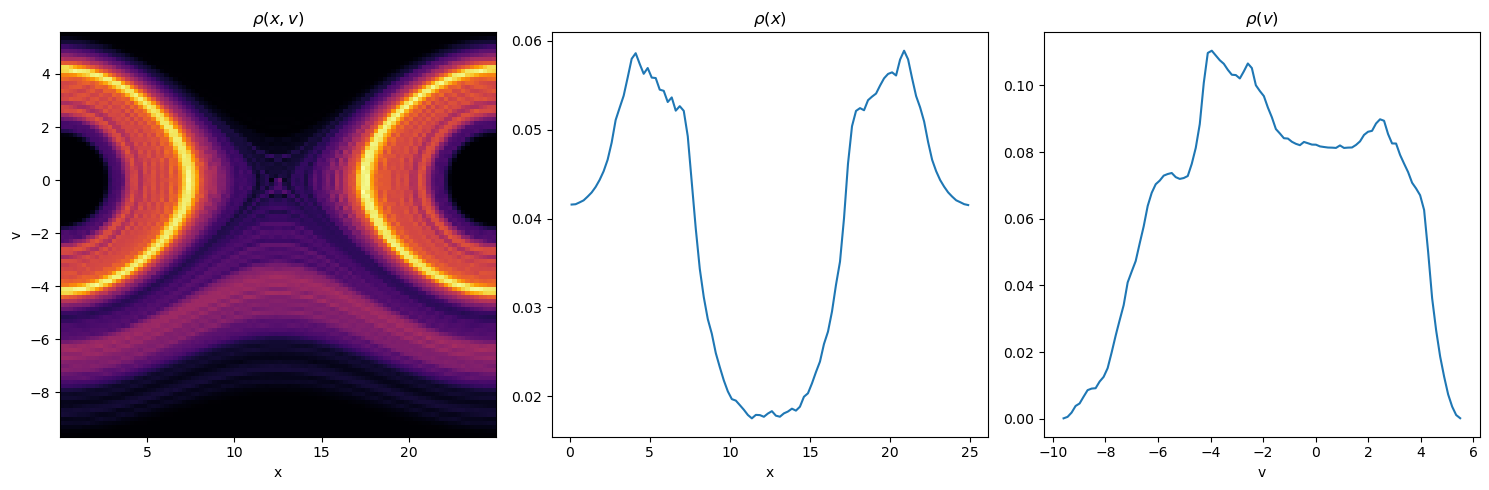

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Joint
axes[0].pcolormesh(x_centers, v_centers, hist2d.T, cmap='inferno')
axes[0].set_title(r'$\rho(x, v)$')
axes[0].set_xlabel('x'); axes[0].set_ylabel('v')

# Marginal ρ(x)
rho_xc2 = hist2d.sum(axis=1) * np.diff(v_edges)[0]
axes[1].plot(x_centers, rho_xc2)
axes[1].set_title(r'$\rho(x)$')
axes[1].set_xlabel('x')

# Marginal ρ(v)
rho_v = hist2d.sum(axis=0) * np.diff(x_edges)[0]
axes[2].plot(v_centers, rho_v)
axes[2].set_title(r'$\rho(v)$')
axes[2].set_xlabel('v')

plt.tight_layout()
plt.show()

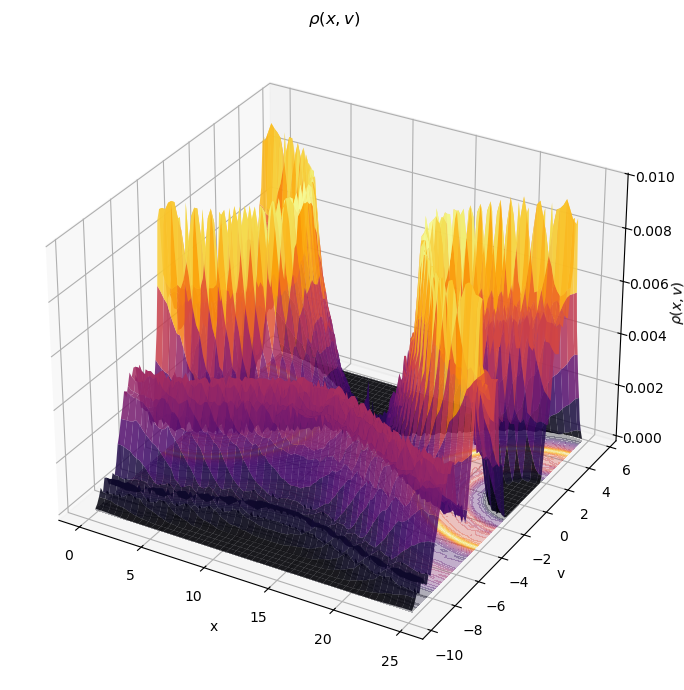

In [42]:
from mpl_toolkits.mplot3d import Axes3D

X, V = np.meshgrid(x_centers, v_centers)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Surface
ax.plot_surface(X, V, hist2d.T, cmap='inferno', edgecolor='none', alpha=0.85)

# Project contours onto the floor for easier reading
ax.contourf(X, V, hist2d.T, zdir='z', offset=0, cmap='inferno', alpha=0.3, levels=20)

ax.set_xlabel('x')
ax.set_ylabel('v')
ax.set_zlabel(r'$\rho(x, v)$')
ax.set_title(r'$\rho(x, v)$')

# Good default viewing angle for phase space
ax.view_init(elev=30, azim=-60)
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Phase portrait — 1 run')

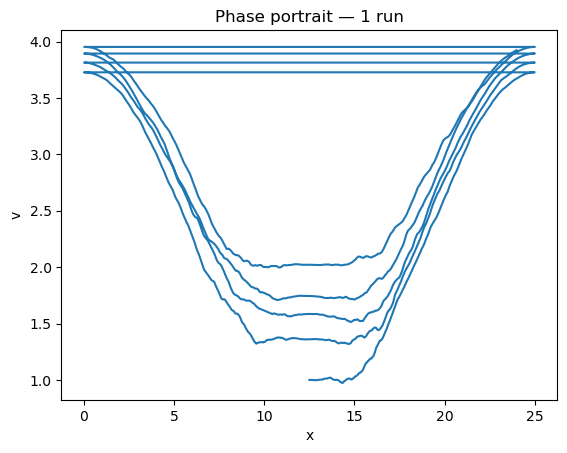

In [496]:
plt.plot(x_all[9,:10000], v_all[9,:10000])
plt.xlabel('x'); plt.ylabel('v')
plt.title('Phase portrait — 1 run')

Text(0.5, 1.0, 'Phase portrait — multiple runs')

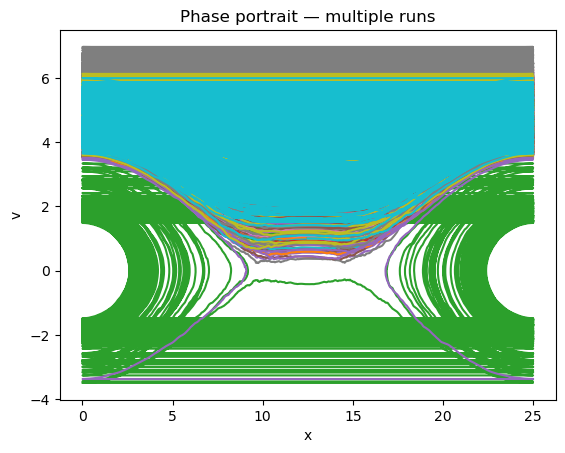

In [497]:
for run in range(len(x_all)):
    plt.plot(x_all[run,:], v_all[run,:])
plt.xlabel('x'); plt.ylabel('v')
plt.title('Phase portrait — multiple runs')

In [143]:
vstation = v_all[:,-50000:].reshape(-1)
#vredstation = vred_all[:,-100000:].reshape(-1)
xstation = x_all[:,-50000:].reshape(-1)
#xredstation = xred_all[:,-100000:].reshape(-1)
vv=np.linspace(min(vstation), max(vstation), 10000)
xx = np.linspace(min(xstation), max(xstation), 10000)
rho_x_valsxx = np.array([rho_x(x) for x in xx])

TypeError: 'numpy.ndarray' object is not callable

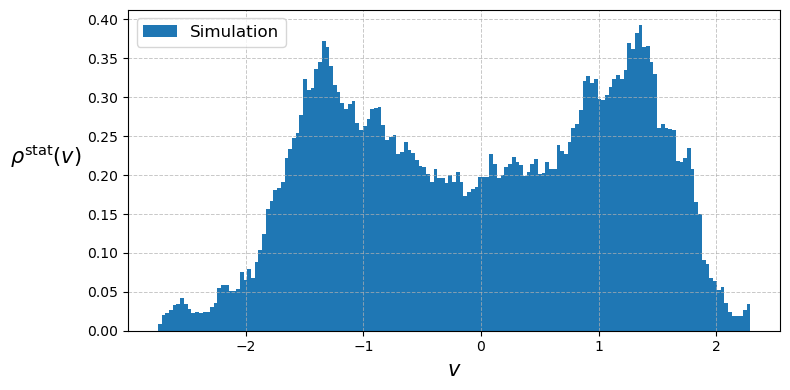

In [144]:
fig, ax = plt.subplots(figsize=(8, 4))
#plt.hist(vredstation, density = True, bins = "auto", label = "Reduced dynamics")
plt.hist(vstation, density = True, bins = "auto", label = "Simulation")
#plt.plot(vv, marginalv(vv), label = "Equilibrium Distribution",color = "black", linestyle = "--")
ax.set_ylabel(r"$\rho^\text{stat}(v)$", fontsize = 15, rotation = 0,labelpad=30)
ax.set_xlabel(r"$v$", fontsize = 15)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
ax.legend(fontsize = 12)
plt.tight_layout()
plt.show()

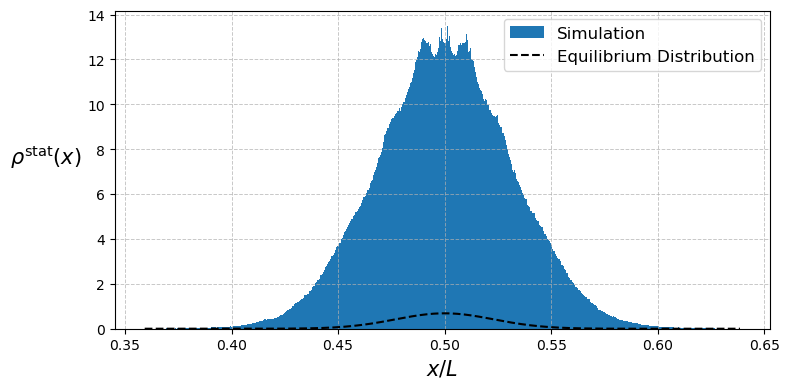

In [41]:
fig, ax = plt.subplots(figsize=(8, 4))
#plt.hist(xredstation, bins = "auto", density = True, label = "Reduced dynamics")
plt.hist(xstation/L,bins = "auto", density = True, label = "Simulation")
plt.plot(xx/L, rho_x_valsxx, label = "Equilibrium Distribution",color = "black", linestyle = "--")
ax.set_ylabel(r"$\rho^\text{stat}(x)$", fontsize = 15, rotation = 0,labelpad=30)
ax.set_xlabel(r"$x/L$", fontsize = 15)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
ax.legend(fontsize = 12)
plt.tight_layout()
plt.show()

In [81]:
vc

3.1622776601683795

In [128]:
np.save("x_allneqrotstrong50.npy", x_all)
np.save("v_allneqrotstrong50.npy", v_all)
np.save("timeseqrotstrong50.npy", times)